# Análisis Exploratorio de Datos (EDA)

## Wall-Following Robot Navigation

Este notebook realiza la carga y exploración inicial del conjunto de datos
Wall-Following Robot Navigation, compuesto por lecturas de 24 sensores
ultrasónicos del robot SCITOS-G5 y una variable objetivo que representa
la acción de navegación realizada por el robot.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [3]:
columnas = [f"sensor_{i}" for i in range(1, 25)] + ["clase"]

ruta = "../data/raw/sensor_readings_24.data"

df = pd.read_csv(
    ruta,
    header=None,
    names=columnas
)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [4]:
df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,clase
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [5]:
# Dimensiones del dataset
print("Dimensiones del dataset:", df.shape)
print("Número de instancias:", df.shape[0])
print("Número total de columnas:", df.shape[1])
print("Número de atributos:", df.shape[1] - 1)

Dimensiones del dataset: (5456, 25)
Número de instancias: 5456
Número total de columnas: 25
Número de atributos: 24


In [6]:
# Tipos de datos
df.dtypes

sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17    float64
sensor_18    float64
sensor_19    float64
sensor_20    float64
sensor_21    float64
sensor_22    float64
sensor_23    float64
sensor_24    float64
clase            str
dtype: object

In [7]:
# Primeras filas del dataset
df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,clase
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [8]:
# Estadísticas descriptivas
df.describe()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24
count,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000,...,5456.000000,5456.000000,5456.000000,5456.000000,5456.00000,5456.000000,5456.000000,5456.000000,5456.000000,5456.000000
mean,1.471617,2.327043,2.489347,2.796501,2.958552,2.893073,3.351113,2.540397,3.125621,2.832386,...,2.205772,1.202111,0.989831,0.910273,1.05811,1.076320,1.015923,1.778034,1.555045,1.578508
std,0.802801,1.410146,1.247435,1.309368,1.339225,1.282575,1.413692,1.111554,1.356965,1.307843,...,1.715435,1.098568,0.942075,0.889527,1.14463,1.141498,0.887439,1.571686,1.291447,1.150480
min,0.400000,0.437000,0.470000,0.833000,1.120000,1.114000,1.122000,0.859000,0.836000,0.810000,...,0.495000,0.424000,0.373000,0.354000,0.34000,0.355000,0.380000,0.370000,0.367000,0.377000
25%,0.921000,1.362000,1.538750,1.731000,1.774000,1.785750,1.930750,1.618000,1.799750,1.636000,...,0.860000,0.690000,0.581000,0.529750,0.52300,0.541750,0.567000,0.743000,0.792000,0.884000
50%,1.335000,1.904500,2.064000,2.458000,2.667000,2.682500,3.225500,2.172000,2.802000,2.679000,...,1.328500,0.803000,0.738000,0.685000,0.69100,0.693000,0.764000,1.030500,1.071000,1.289000
75%,1.814000,2.681500,2.739250,4.093500,4.314500,3.835250,5.000000,3.193000,5.000000,3.526250,...,4.436250,1.159000,0.913000,0.837000,0.85700,0.863000,1.002250,2.068250,1.559500,1.657250
max,5.000000,5.025000,5.029000,5.017000,5.000000,5.005000,5.008000,5.087000,5.000000,5.022000,...,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000


### Variable objetivo

La variable objetivo del conjunto de datos es `clase`. Esta variable representa
la acción de navegación que debe realizar el robot a partir de las lecturas
obtenidas mediante sus 24 sensores ultrasónicos.

# Clases presentes en la variable objetivo
print("Variable objetivo: clase")
print("\nClases disponibles:")

print(df["clase"].unique())

In [9]:
# Clases presentes en la variable objetivo
print("Variable objetivo: clase")
print("\nClases disponibles:")

print(df["clase"].unique())

Variable objetivo: clase

Clases disponibles:
<ArrowStringArray>
['Slight-Right-Turn', 'Sharp-Right-Turn', 'Move-Forward', 'Slight-Left-Turn']
Length: 4, dtype: str


In [10]:
# Distribución de la variable objetivo
balance_clases = df["clase"].value_counts()

print("Cantidad de observaciones por clase:")
print(balance_clases)

print("\nPorcentaje por clase:")
print((df["clase"].value_counts(normalize=True) * 100).round(2))

Cantidad de observaciones por clase:
clase
Move-Forward         2205
Sharp-Right-Turn     2097
Slight-Right-Turn     826
Slight-Left-Turn      328
Name: count, dtype: int64

Porcentaje por clase:
clase
Move-Forward         40.41
Sharp-Right-Turn     38.43
Slight-Right-Turn    15.14
Slight-Left-Turn      6.01
Name: proportion, dtype: float64


# EDA completo

En esta sección se profundiza en el análisis exploratorio del conjunto de datos
mediante visualizaciones que permiten estudiar la distribución de las variables,
identificar posibles valores atípicos, analizar relaciones entre los sensores y
examinar la distribución de la variable objetivo.

## Distribución de las variables

Se analizan las distribuciones de seis sensores ultrasónicos mediante histogramas.
Estos gráficos permiten observar la frecuencia de las distintas distancias
registradas por los sensores durante la navegación del robot.

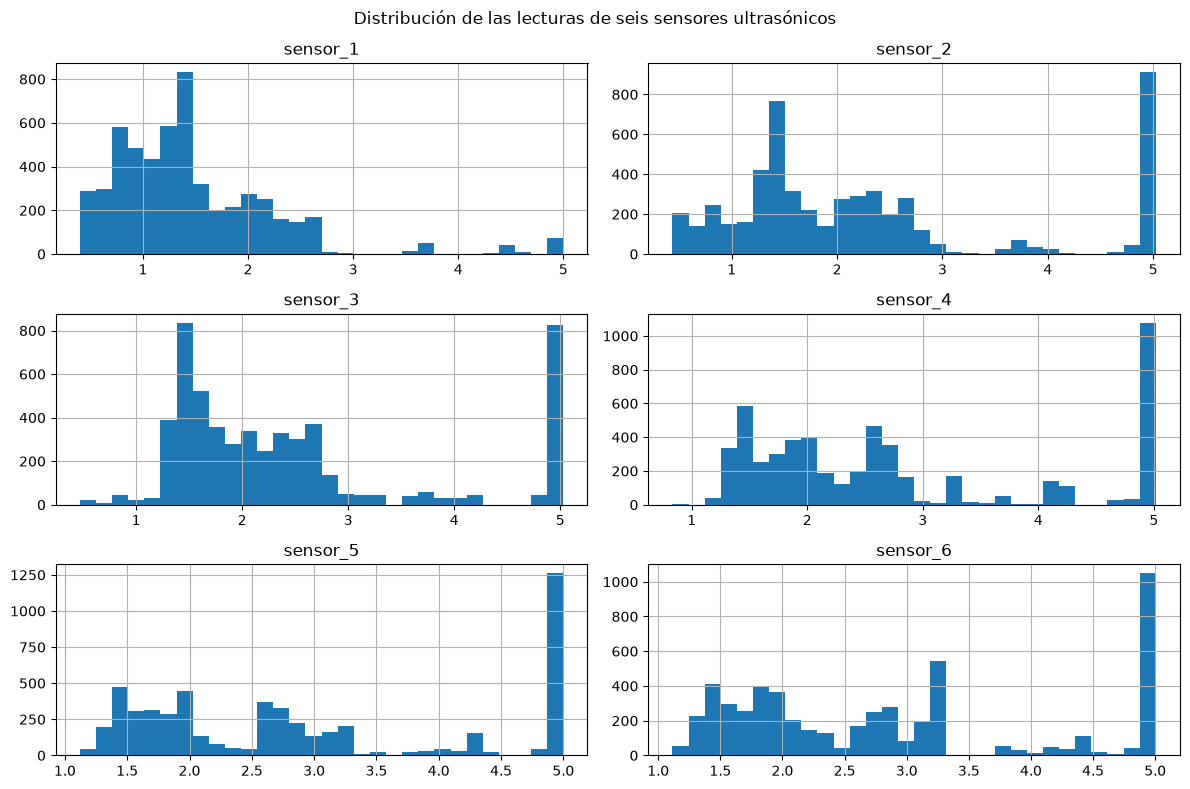

In [11]:
# Selección de seis sensores para el análisis
sensores_hist = [
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6"
]

df[sensores_hist].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Distribución de las lecturas de seis sensores ultrasónicos")
plt.tight_layout()
plt.show()

## Detección visual de valores atípicos

Los diagramas de caja permiten identificar observaciones que se encuentran
alejadas del comportamiento central de las lecturas. Estos valores no se
eliminan automáticamente, ya que pueden representar mediciones reales obtenidas
por los sensores durante la navegación del robot.

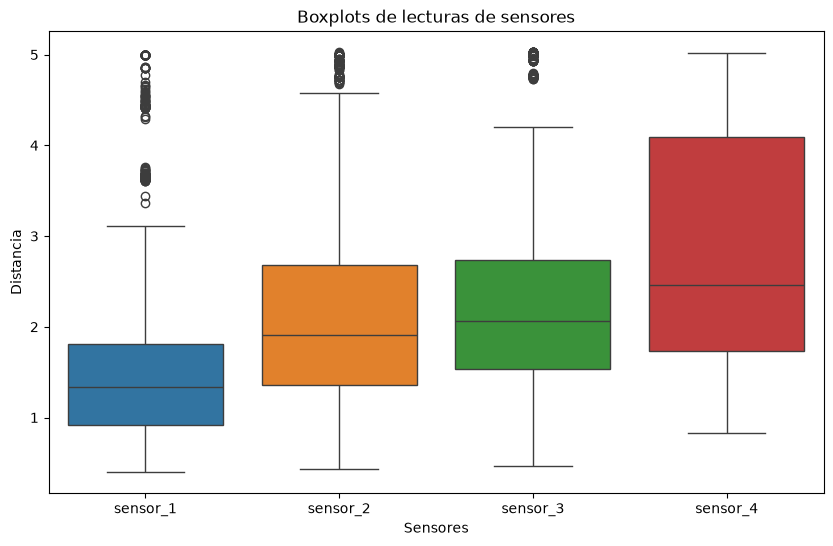

In [12]:
sensores_boxplot = [
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4"
]

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[sensores_boxplot])

plt.title("Boxplots de lecturas de sensores")
plt.xlabel("Sensores")
plt.ylabel("Distancia")
plt.show()

## Correlación entre sensores

La matriz de correlación permite analizar el grado de relación lineal existente
entre las lecturas de los 24 sensores ultrasónicos. Valores cercanos a 1 indican
una relación positiva fuerte, mientras que valores cercanos a -1 representan
una relación negativa fuerte.

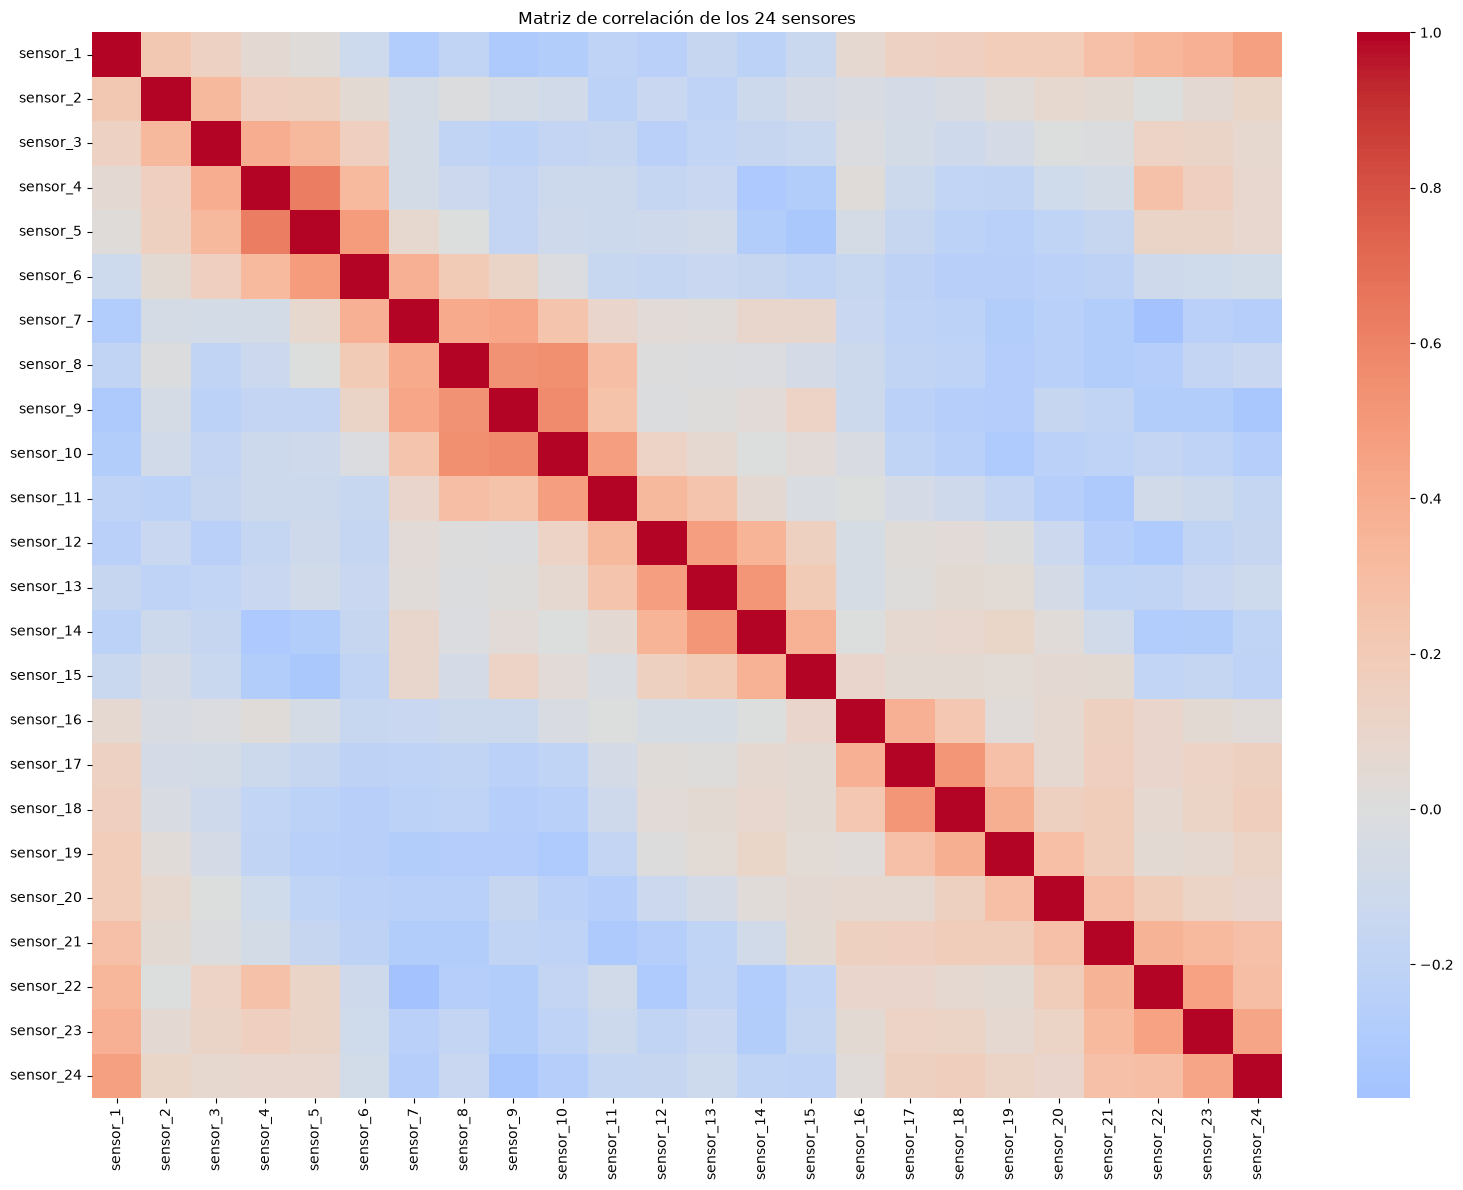

In [13]:
# Seleccionar únicamente las variables numéricas
sensores = [f"sensor_{i}" for i in range(1, 25)]

correlacion = df[sensores].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlacion,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de los 24 sensores")
plt.tight_layout()
plt.show()

## Distribución de la variable objetivo

Se analiza la cantidad de observaciones correspondientes a cada acción de
navegación. Esto permite determinar si las clases se encuentran balanceadas
o si algunas acciones tienen una representación mayor dentro del dataset.

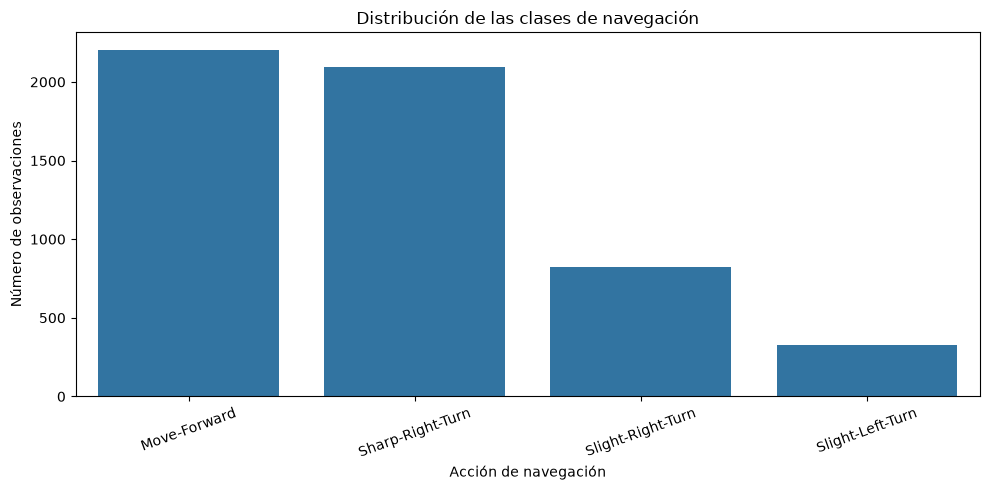

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="clase",
    order=df["clase"].value_counts().index
)

plt.title("Distribución de las clases de navegación")
plt.xlabel("Acción de navegación")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Generación del resumen del EDA

Se genera un archivo JSON que resume las principales características del
conjunto de datos, incluyendo sus dimensiones, valores faltantes,
estadísticas descriptivas y distribución de la variable objetivo.

In [15]:
import json
from pathlib import Path

# Construcción del resumen del EDA
eda_summary = {
    "dimensiones": {
        "numero_instancias": int(df.shape[0]),
        "numero_atributos": int(df.shape[1] - 1)
    },
    
    "valores_faltantes": {
        columna: int(valor)
        for columna, valor in df.isnull().sum().items()
    },
    
    "estadisticas_descriptivas": df.describe().to_dict(),
    
    "distribucion_clases": {
        str(clase): int(cantidad)
        for clase, cantidad in df["clase"].value_counts().items()
    }
}

In [16]:
# Ruta donde se guardará el archivo
ruta_json = Path("../data/processed/eda_summary.json")

# Crear la carpeta si no existe
ruta_json.parent.mkdir(parents=True, exist_ok=True)

# Guardar el resumen
with open(ruta_json, "w", encoding="utf-8") as archivo:
    json.dump(eda_summary, archivo, indent=4, ensure_ascii=False)

print(f"Archivo generado correctamente: {ruta_json}")

Archivo generado correctamente: ..\data\processed\eda_summary.json


In [17]:
with open(ruta_json, "r", encoding="utf-8") as archivo:
    resumen_verificacion = json.load(archivo)

print("Secciones del archivo JSON:")
for seccion in resumen_verificacion.keys():
    print("-", seccion)

Secciones del archivo JSON:
- dimensiones
- valores_faltantes
- estadisticas_descriptivas
- distribucion_clases
